In [6]:
import requests
from bs4 import BeautifulSoup

url = "https://nhasachmienphi.com/doc-online/lich-su-viet-nam-tu-nguon-goc-den-nam-1884-306929"
headers = {"User-Agent": "Mozilla/5.0"}

r = requests.get(url, headers=headers)
r.raise_for_status()
soup = BeautifulSoup(r.text, "html.parser")


container = soup.select_one("div.content_p.fs-16.content_p_al")

if not container:
    raise RuntimeError("Không tìm thấy div nội dung chính, kiểm tra lại cấu trúc HTML.")

#lấy thẻ
paras = container.find_all("p")

paras = [p.get_text(" ", strip=True) for p in paras if p.get_text(strip=True)]

print("Tổng số đoạn văn:", len(paras))
if paras:
    print("Preview:", paras[0][:200], "...")


text = "\n\n".join(paras)


with open("Cau1.txt", "w", encoding="utf-8") as f:
    f.write(text)

Tổng số đoạn văn: 120
Preview: I. Nước Văn Lang – Họ Hồng Bàng (2879 (?) – 258 tr.CN) Đây là giai đoạn mang tính chất nửa lịch sử nửa thần thoại khi con người Việt cổ còn chưa có chữ viết. Lịch sử chỉ được ghi nhớ lại qua truyền kh ...


In [7]:
import os
import re
import string
import requests
import emoji
from underthesea import sent_tokenize, word_tokenize


stopwords_url = "https://raw.githubusercontent.com/stopwords/vietnamese-stopwords/master/vietnamese-stopwords.txt"
stopwords_path = "vietnamese-stopwords.txt"

if not os.path.exists(stopwords_path):
    r = requests.get(stopwords_url)
    with open(stopwords_path, "w", encoding="utf-8") as f:
        f.write(r.text)

with open(stopwords_path, "r", encoding="utf-8") as f:
    stopwords_vn = set([line.strip() for line in f if line.strip()])

print(f" done {len(stopwords_vn)} stopwords.")


def preprocess_text(text):
   
    text = text.lower()
   
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)
   
    text = text.translate(str.maketrans("", "", string.punctuation))
    # 4. Xóa chữ số
    text = re.sub(r"\d+", "", text)
    # 5. emoji
    text = emoji.demojize(text)

    # 6. Tách câu trông đoạn văn bản
    sentences = sent_tokenize(text)

    processed_sentences = []
    for sent in sentences:
       
        tokens = word_tokenize(sent, format="text").split()
        # 8. Xóa stopwords
        tokens = [w for w in tokens if w not in stopwords_vn]
        processed_sentences.append(" ".join(tokens))

#chuẩn hóa
    return " ".join(processed_sentences).strip()


input_file = "Cau1.txt"
output_file = "Cau1_txl.txt"

if not os.path.exists(input_file):
    raise FileNotFoundError(f"Không tìm thấy file {input_file}")

print(f"🔧 Đang xử lý file: {input_file} ...")

with open(input_file, "r", encoding="utf-8", errors="ignore") as f:
    raw_text = f.read()

processed_text = preprocess_text(raw_text)

with open(output_file, "w", encoding="utf-8") as f:
    f.write(processed_text)

print(f" Hoàn tất! Đã lưu kết quả vào {output_file} ({len(processed_text.split())} từ).")

 done 1942 stopwords.
🔧 Đang xử lý file: Cau1.txt ...
 Hoàn tất! Đã lưu kết quả vào Cau1_txl.txt (5676 từ).


In [8]:
from collections import Counter

# Giả sử bạn đã có biến processed_text ở bước trước
tokens = processed_text.split()  # tách thành danh sách từ
word_freq = Counter(tokens)

# Xem 20 từ xuất hiện nhiều nhất
print(word_freq.most_common(20))

# Lưu ra file
with open("Cau1_freq.txt", "w", encoding="utf-8") as f:
    for word, freq in word_freq.most_common():
        f.write(f"{word}\t{freq}\n")

print("Đã lưu thống kê tần suất từ vào Cau1_freq.txt")

[('thành', 204), ('cửa', 54), ('sông', 50), ('“', 44), ('”', 44), ('đất', 44), ('hai', 42), ('vua', 40), ('cổ_loa', 40), ('m', 38), ('đền', 38), ('xây', 34), ('gọi_là', 32), ('núi', 30), ('nam', 28), ('thủy', 24), ('thời', 24), ('dân', 24), ('mặt', 24), ('đường', 24)]
Đã lưu thống kê tần suất từ vào Cau1_freq.txt


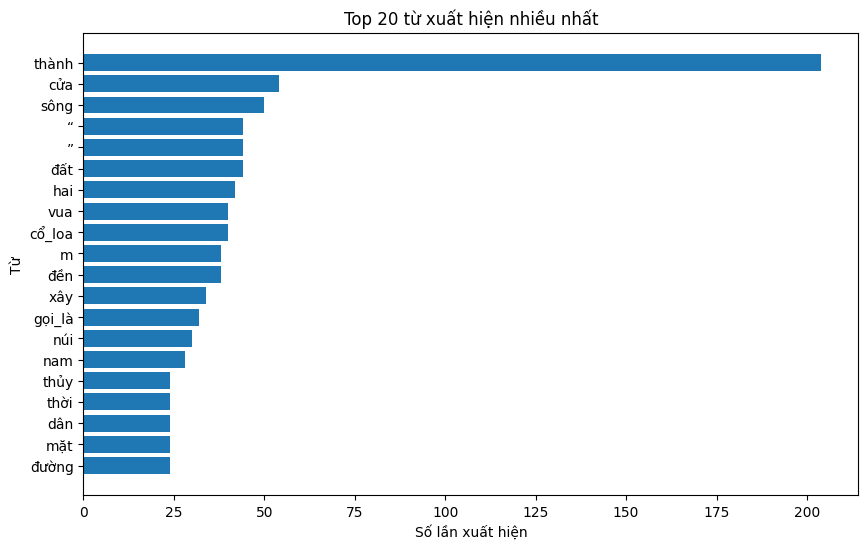

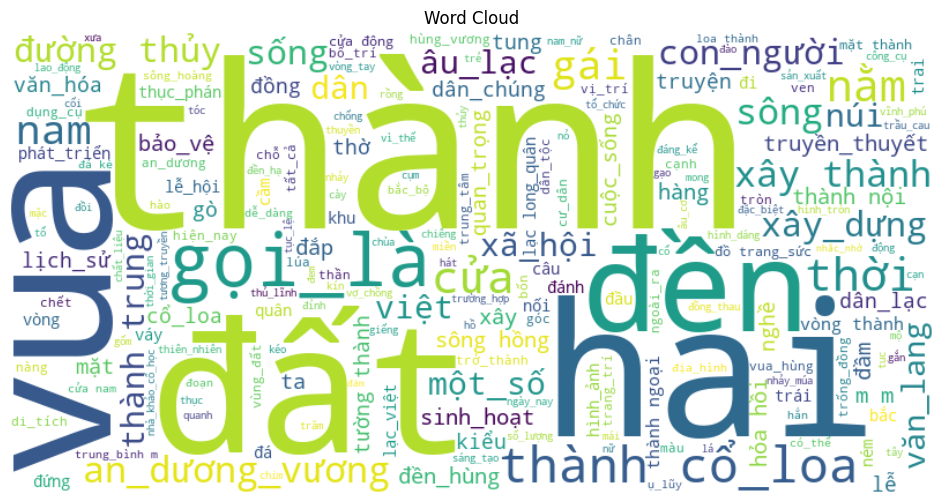

In [9]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from collections import Counter

# === Sau khi đã chạy tiền xử lý và có processed_text ===
tokens = processed_text.split()  # danh sách từ sau tiền xử lý

# Đếm tần suất từ
word_freq = Counter(tokens)

# Vẽ biểu đồ tần suất 20 từ xuất hiện nhiều nhất
top_words = word_freq.most_common(20)
words, counts = zip(*top_words)

plt.figure(figsize=(10,6))
plt.barh(words, counts)
plt.gca().invert_yaxis()  
plt.xlabel("Số lần xuất hiện")
plt.ylabel("Từ")
plt.title("Top 20 từ xuất hiện nhiều nhất")
plt.show()

# === WordCloud ===
wordcloud = WordCloud(width=800, height=400, background_color="white").generate(" ".join(tokens))

plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Word Cloud")
plt.show()
